In [16]:
%load_ext autoreload
%autoreload 2

from scripts.ingestion import *
from scripts.data_qc import *
from scripts.poke_detection import *
from constants import Z_FORCE_SENSOR_TO_NEWTON

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import re

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
data_dir = "/Users/jiayi/Princeton Dropbox/Jiayi Zhang/sensetics/04_14_map_study_2"
data_dir = "/Users/jiayi/Princeton Dropbox/Jiayi Zhang/sensetics/04_29_disp_study"
session_index = build_sessions_index(data_dir)

In [38]:
disp_info_fp = "./sensetics_map_study_y.csv"
disp_info_df = pd.read_csv(disp_info_fp)
disp_dict = {y: float(disp[5:]) for y, disp in zip(disp_info_df["Y_POS"], disp_info_df["NOTES"])}

base_disp = 0.2

In [39]:
x_poses = session_index["x_um"].unique().to_numpy()
y_poses = session_index["y_um"].unique().to_numpy()

x_poses = x_poses[~np.isnan(x_poses)]
y_poses = y_poses[~np.isnan(y_poses)]

x_poses.sort()
y_poses.sort()

In [40]:
features_all = []
features_norm_all = []
xs = []

for x in x_poses:
    query = pl.col("x_um") == x
    # get the latest sessino for this x position
    filtered = session_index.filter(query)
    filtered = filtered.sort("time_hhmm", descending=True).to_dicts()[0]

    fs = filtered["fs_hz"]
    pdf = load_session_pandas(filtered, flip=True)
    N_cap = filtered["saved_sweeps"]

    min_height = 50
    n_discard, pdf_trim, mixed_pos, final_peaks = poke_detection(pdf, fs, N_cap, height=min_height, min_sep_ms=500)
    poke_windows = extract_poke_windows(pdf_trim, final_peaks, fs, pre_ms=50.0, post_ms=100.0)

    force_peaks, F = force_peak_detection(pdf_trim, fs, height=1500, min_sep_ms=500)
    print(f"x={x}, detected {len(final_peaks)} pokes, force peaks: {len(force_peaks)}")
    assert len(final_peaks) == len(force_peaks), "Number of poke peaks and force peaks should match"

    events = annotate_pokes_from_peaks(final_peaks, mixed_pos, fs)
    poke_windows = extract_poke_windows_from_annotations(pdf_trim, events, fs, pad_pre_ms=150, pad_post_ms=300.0)
    
    # control for abnormal poke windows
    poke_windows, invalid_mask = remove_partial_peak(poke_windows)
    force_peaks = [p for i, p in enumerate(force_peaks) if not invalid_mask[i]]

    # features = extract_sensor_peak_strength_session(poke_windows, fs, t_ref_ms=150)
    features = extract_sensor_peak_strength_from_annotation_session(poke_windows, fs, pad_pre_peak_ms=50, pad_post_peak_ms=50, subtract_baseline=False)

    peak_fs = extract_force_peak_strength(pdf_trim, force_peaks, fs, pre_ms=250, post_ms=250, quant=0.95)

    # extract features
    features["force_peak"] = peak_fs / Z_FORCE_SENSOR_TO_NEWTON
    features["x"] = x
    drop_cols = ["force_peak", "x"]
    feature_cols = features.columns.drop(drop_cols)
    features_all.append(features)

    df_norm = features.copy()
    df_norm[feature_cols] = df_norm[feature_cols].div(df_norm["force_peak"], axis=0)

    features_norm_all.append(df_norm)
    

x_all_features_df = pd.concat(features_all, ignore_index=True)
x_all_features_norm_df = pd.concat(features_norm_all, ignore_index=True)
    

ValueError: No objects to concatenate

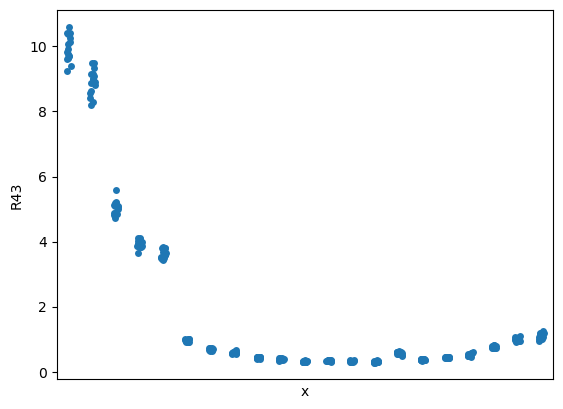

In [41]:
x_all_features_df["R13"] =  x_all_features_df["CH1_p2p99"] / x_all_features_df["CH3_p2p99"]
x_all_features_df["R43"] =  x_all_features_df["CH4_p2p99"] / x_all_features_df["CH3_p2p99"]
sns.stripplot(data=x_all_features_df, x="x", y="R43")

# sns.stripplot(data=x_all_features_norm_df, x="x", y="force_peak")
# # sns.stripplot(data=y_all_features_norm_df, x="y", y="force_peak")
# sns.stripplot(data=x_all_features_df, x="x", y="CH4_p2p99")
# sns.stripplot(data=x_all_features_df, x="x", y="CH2_p2p99")
# set xticks to be integers
_ = plt.xticks(ticks=np.arange(len(x_poses)), labels=[str(int(x)) for x in x_poses])
_ = plt.xticks(rotation=45)

In [42]:
features_all = []
features_norm_all = []
ys = []

for y in y_poses:
    query = pl.col("y_um") == y
    # get the latest sessino for this y position
    filtered = session_index.filter(query)
    filtered = filtered.sort("time_hhmm", descending=True).to_dicts()[0]

    fs = filtered["fs_hz"]
    pdf = load_session_pandas(filtered, flip=True)
    N_cap = filtered["saved_sweeps"]

    min_height = 50
    n_discard, pdf_trim, mixed_pos, final_peaks = poke_detection(pdf, fs, N_cap, height=min_height, min_sep_ms=500)
    poke_windows = extract_poke_windows(pdf_trim, final_peaks, fs, pre_ms=50.0, post_ms=100.0)

    force_peaks, F = force_peak_detection(pdf_trim, fs, height=1500, min_sep_ms=500)
    print(f"y={y}, detected {len(final_peaks)} pokes, force peaks: {len(force_peaks)}")
    assert len(final_peaks) == len(force_peaks), "Number of poke peaks and force peaks should match"

    events = annotate_pokes_from_peaks(final_peaks, mixed_pos, fs)
    poke_windows = extract_poke_windows_from_annotations(pdf_trim, events, fs, pad_pre_ms=150, pad_post_ms=300.0)
    
    # control for abnormal poke windows
    poke_windows, invalid_mask = remove_partial_peak(poke_windows)
    force_peaks = [p for i, p in enumerate(force_peaks) if not invalid_mask[i]]

    # features = extract_sensor_peak_strength_session(poke_windows, fs, t_ref_ms=150)
    features = extract_sensor_peak_strength_from_annotation_session(poke_windows, fs, pad_pre_peak_ms=50, pad_post_peak_ms=50, subtract_baseline=False)

    peak_fs = extract_force_peak_strength(pdf_trim, force_peaks, fs, pre_ms=250, post_ms=250, quant=0.95)

    # extract features
    features["force_peak"] = peak_fs / Z_FORCE_SENSOR_TO_NEWTON
    features["y"] = y
    drop_cols = ["force_peak", "y"]
    feature_cols = features.columns.drop(drop_cols)
    features_all.append(features)

    df_norm = features.copy()
    df_norm[feature_cols] = df_norm[feature_cols].div(df_norm["force_peak"], axis=0)

    features_norm_all.append(df_norm)
    

y_all_features_df = pd.concat(features_all, ignore_index=True)
y_all_features_norm_df = pd.concat(features_norm_all, ignore_index=True)
    

y=-1800, detected 25 pokes, force peaks: 25
Removing 0 out of 25 poke windows due to partial peaks
y=-1200, detected 25 pokes, force peaks: 25
Removing 0 out of 25 poke windows due to partial peaks
y=600, detected 25 pokes, force peaks: 25
Removing 0 out of 25 poke windows due to partial peaks


<Axes: xlabel='y', ylabel='R53'>

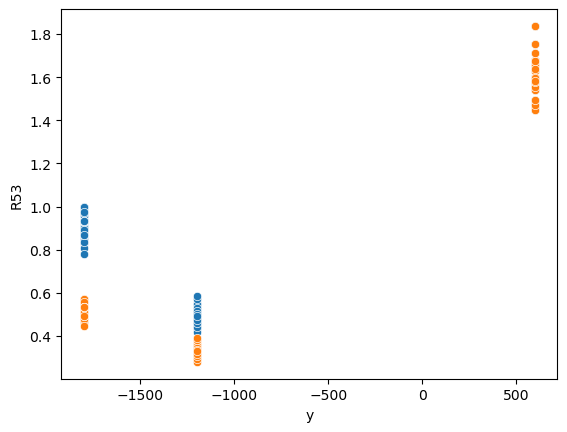

In [43]:
new_features = y_all_features_df.copy()
new_features["R53"] = new_features["CH5_p2p99"] / new_features["CH3_p2p99"]
new_features["DISP"] = new_features["y"].map(disp_dict)
new_features["R53_disp_norm"] = new_features["R53"] * (base_disp/new_features["DISP"])
sns.scatterplot(data=new_features, x="y", y="R53")
sns.scatterplot(data=new_features, x="y", y="R53_disp_norm")

<Axes: xlabel='y', ylabel='R23'>

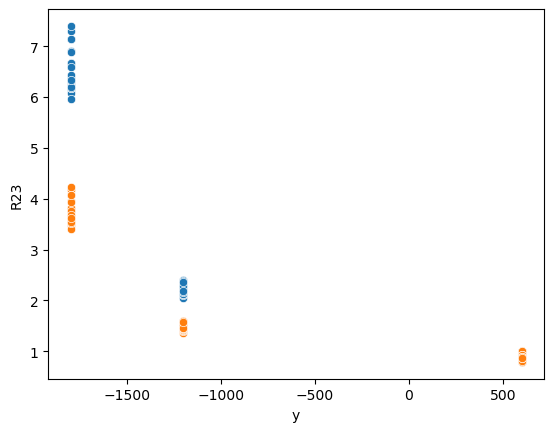

In [44]:
new_features = y_all_features_df.copy()
new_features["R23"] = new_features["CH2_p2p99"] / new_features["CH3_p2p99"]
new_features["DISP"] = new_features["y"].map(disp_dict)
new_features["R23_disp_norm"] = new_features["R23"] * (base_disp/new_features["DISP"])
sns.scatterplot(data=new_features, x="y", y="R23")
sns.scatterplot(data=new_features, x="y", y="R23_disp_norm")

In [49]:
y_all_features_df[y_all_features_df["y"] == 600]["force_peak"]

50    1.303652
51    1.296881
52    1.310756
53    1.310645
54    1.239687
55    1.307327
56    1.267505
57    1.298952
58    1.284765
59    1.263407
60    1.305589
61    1.246926
62    1.275879
63    1.290667
64    1.306369
65    1.291870
66    1.256903
67    1.305656
68    1.309376
69    1.286012
70    1.287883
71    1.314008
72    1.306592
73    1.278329
74    1.306658
Name: force_peak, dtype: float64

In [25]:
# sns.stripplot(data=y_all_features_norm_df, x="y", y="CH5_p2p99")
sns.stripplot(data=y_all_features_norm_df, x="y", y="CH1_p2p")

# sns.stripplot(data=y_all_features_norm_df, x="y", y="CH4_p2p99")
# sns.stripplot(data=y_all_features_norm_df, x="y", y="CH2_p2p99")
# set xticks to be integers
_ = plt.xticks(ticks=np.arange(len(y_poses)), labels=[str(int(y)) for y in y_poses])
_ = plt.xticks(rotation=45)

ValueError: Could not interpret value `CH1_p2p` for `y`. An entry with this name does not appear in `data`.

In [ ]:
new_features = y_all_features_df.copy()
new_features["R53"] = new_features["CH5_p2p99"] / new_features["CH3_p2p99"]
sns.scatterplot(data=new_features, x="note", y="R53")

---
### Example locations

In [ ]:
y = 600
query = pl.col("y_um") == y
# get the latest sessino for this y position
filtered = session_index.filter(query)
print(filtered["notes"])
filtered = filtered.sort("time_hhmm", descending=True).to_dicts()[0]
# print(filtered["notes"])

fs = filtered["fs_hz"]
pdf = load_session_pandas(filtered, flip=True)
N_cap = filtered["saved_sweeps"]

shape: (5,)
Series: 'notes' [str]
[
	"disp=0.25"
	"disp=0.4"
	"disp=0.3"
	"disp=0.35"
	"disp=0.2"
]


In [27]:
min_height = 50
n_discard, pdf_trim, mixed_pos, final_peaks = poke_detection(pdf, fs, N_cap, height=min_height, min_sep_ms=300)
poke_windows = extract_poke_windows(pdf_trim, final_peaks, fs, pre_ms=50.0, post_ms=100.0)

force_peaks, F = force_peak_detection(pdf_trim, fs, height=1500, min_sep_ms=500)
print(f"y={y}, detected {len(final_peaks)} pokes, force peaks: {len(force_peaks)}")

y=2200.0, detected 18 pokes, force peaks: 18


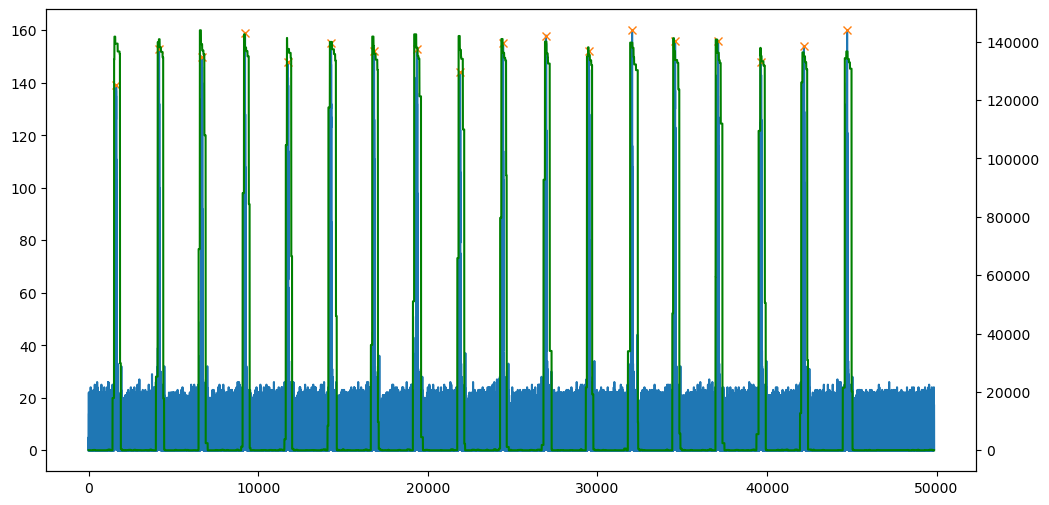

In [32]:
f, ax = plt.subplots(figsize=(12, 6))
ax.plot(mixed_pos)
ax.plot(final_peaks, mixed_pos[final_peaks], "x")
# twin axis for force
ax2 = ax.twinx()
ax2.plot(F, color="green")

In [33]:
events = annotate_pokes_from_peaks(final_peaks, mixed_pos, fs)
poke_windows = extract_poke_windows_from_annotations(pdf_trim, events, fs, pad_pre_ms=150, pad_post_ms=300.0)

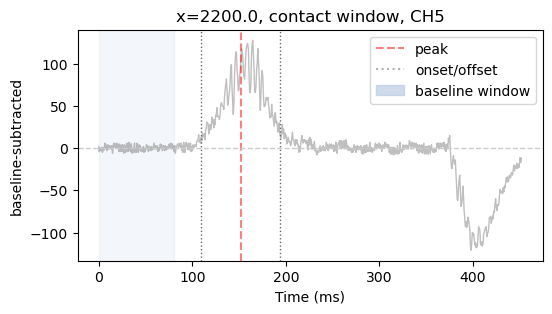

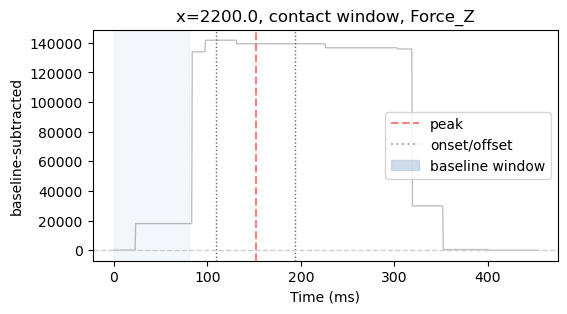

In [34]:
ch = "CH5"
f = plot_poke_windows(poke_windows, fs, ch=f"{ch}", n=1,
                      title=f"x={x}, contact window, {ch}")

f = plot_poke_windows(poke_windows, fs, ch="Force_Z", n=1,
                      title=f"x={x}, contact window, Force_Z")

In [ ]:
ch = "CH5"
f = plot_poke_windows(poke_windows, fs, ch=f"{ch}", n=1,
                      title=f"x={x}, contact window, {ch}")

f = plot_poke_windows(poke_windows, fs, ch="Force_Z", n=1,
                      title=f"x={x}, contact window, Force_Z")

NameError: name 'plot_poke_windows' is not defined

In [ ]:
def remove_partial_peak(poke_windows):
    n_pokes = len(poke_windows)
    baselines = np.zeros(n_pokes)

    for i, poke in enumerate(poke_windows):
        baseline = [poke["baseline"][k] for k in poke["baseline"].keys()]
        baseline = np.mean(np.array(baseline))
        baselines[i] = baseline

    mean_baseline = np.mean(baselines)
    std_baseline = np.std(baselines)
    threshold_min = 3 * std_baseline # 3 std away from mean
    
    invalid = np.abs(baselines - mean_baseline) > threshold_min
    print(f"Removing {invalid.sum()} out of {n_pokes} poke windows due to partial peaks")

    poke_windows = [p for i, p in enumerate(poke_windows) if not invalid[i]]

    return poke_windows, invalid

    

In [ ]:
features_all = []
features_norm_all = []
y_poses_test = [600]

for y in y_poses_test:
    query = pl.col("y_um") == y
    # get the latest sessino for this y position
    filtered_all = session_index.filter(query).to_dicts()

    for filtered in filtered_all:
        print(filtered["notes"])
    
        fs = filtered["fs_hz"]
        pdf = load_session_pandas(filtered, flip=True)
        N_cap = filtered["saved_sweeps"]

        min_height = 45
        n_discard, pdf_trim, mixed_pos, final_peaks = poke_detection(pdf, fs, N_cap, height=min_height, min_sep_ms=500)
        poke_windows = extract_poke_windows(pdf_trim, final_peaks, fs, pre_ms=50.0, post_ms=100.0)

        force_peaks, F = force_peak_detection(pdf_trim, fs, height=1500, min_sep_ms=500)
        print(f"y={y}, detected {len(final_peaks)} pokes, force peaks: {len(force_peaks)}")
        try:
            assert len(final_peaks) == len(force_peaks), "Number of poke peaks and force peaks should match"
        except AssertionError as e:
            print(len(final_peaks), len(force_peaks))
            continue

        events = annotate_pokes_from_peaks(final_peaks, mixed_pos, fs)
        poke_windows = extract_poke_windows_from_annotations(pdf_trim, events, fs, pad_pre_ms=150, pad_post_ms=300.0)
        
        # control for abnormal poke windows
        poke_windows, invalid_mask = remove_partial_peak(poke_windows)
        force_peaks = [p for i, p in enumerate(force_peaks) if not invalid_mask[i]]

        # features = extract_sensor_peak_strength_session(poke_windows, fs, t_ref_ms=150)
        features = extract_sensor_peak_strength_from_annotation_session(poke_windows, fs, pad_pre_peak_ms=50, pad_post_peak_ms=50, subtract_baseline=False)

        peak_fs = extract_force_peak_strength(pdf_trim, force_peaks, fs, pre_ms=250, post_ms=250, quant=0.95)

        # extract features
        features["force_peak"] = peak_fs / Z_FORCE_SENSOR_TO_NEWTON
        features["y"] = y
        features["note"] = float(re.search(r"disp=([0-9]+\.[0-9]+)", filtered["notes"]).group(1))
        drop_cols = ["force_peak", "y", "note"]
        feature_cols = features.columns.drop(drop_cols)
        features_all.append(features)

        df_norm = features.copy()
        df_norm[feature_cols] = df_norm[feature_cols].div(df_norm["force_peak"], axis=0)

        features_norm_all.append(df_norm)
        

y_all_features_df = pd.concat(features_all, ignore_index=True)
y_all_features_norm_df = pd.concat(features_norm_all, ignore_index=True)
    

disp=0.25
y=600, detected 25 pokes, force peaks: 25
Removing 0 out of 25 poke windows due to partial peaks
disp=0.4
y=600, detected 25 pokes, force peaks: 25
Removing 0 out of 25 poke windows due to partial peaks
disp=0.3
y=600, detected 25 pokes, force peaks: 25
Removing 0 out of 25 poke windows due to partial peaks
disp=0.35
y=600, detected 25 pokes, force peaks: 25
Removing 0 out of 25 poke windows due to partial peaks
disp=0.2
y=600, detected 25 pokes, force peaks: 25
Removing 0 out of 25 poke windows due to partial peaks


In [26]:
y_all_features

NameError: name 'y_all_features' is not defined

Text(0, 0.5, 'CH5 p2p99 / CH3 p2p99')

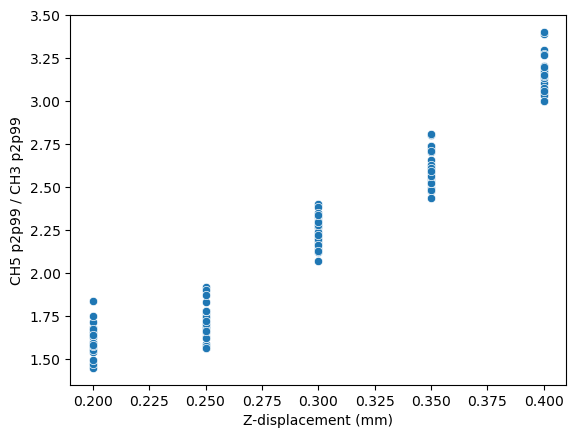

In [ ]:
# sns.scatterplot(data=y_all_features_df, x="y", y="CH5_posmean", hue="note")
# sns.scatterplot(data=y_all_features_df, x="CH5_p2p99", y="CH3_p2p99", hue="note")
new_features = y_all_features_df.copy()
new_features["R53"] = new_features["CH5_p2p99"] / new_features["CH3_p2p99"]
sns.scatterplot(data=new_features, x="note", y="R53")
plt.xlabel("Z-displacement (mm)")
plt.ylabel("CH5 p2p99 / CH3 p2p99")
# plt.ylim(4, 10)